In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("../data/train.csv")
df.head(7)

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0
5,5,2013-01-01,1,BREAD/BAKERY,0.0,0
6,6,2013-01-01,1,CELEBRATION,0.0,0


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.shape

(3000888, 6)

In [6]:
df.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         str    
 2   store_nbr    int64  
 3   family       str    
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 196.8 MB


In [8]:
print([df.duplicated()])

[0          False
1          False
2          False
3          False
4          False
           ...  
3000883    False
3000884    False
3000885    False
3000886    False
3000887    False
Length: 3000888, dtype: bool]


In [9]:
df.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [10]:
df.isnull().sum().sum()

np.int64(0)

In [11]:
df["date"] = pd.to_datetime(df["date"])

In [12]:
df["date"].dtype

dtype('<M8[us]')

In [13]:
print("Number of unique dates:", df["date"].nunique())

Number of unique dates: 1684


In [14]:
df["sales"].describe()

count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64

In [15]:
daily_sales = df.groupby("date")["sales"].sum().reset_index()

In [16]:
daily_sales["date"].nunique()

1684

In [17]:
daily_sales.shape

(1684, 2)

In [18]:
daily_sales.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1679    False
1680    False
1681    False
1682    False
1683    False
Length: 1684, dtype: bool

In [19]:

daily_sales.duplicated().sum()


np.int64(0)

In [20]:
daily_sales.min()


date     2013-01-01 00:00:00
sales            2511.618999
dtype: object

In [21]:
daily_sales.max()

date     2017-08-15 00:00:00
sales         1463083.962459
dtype: object

Text(0.5, 1.0, 'daily_sales_time_series')

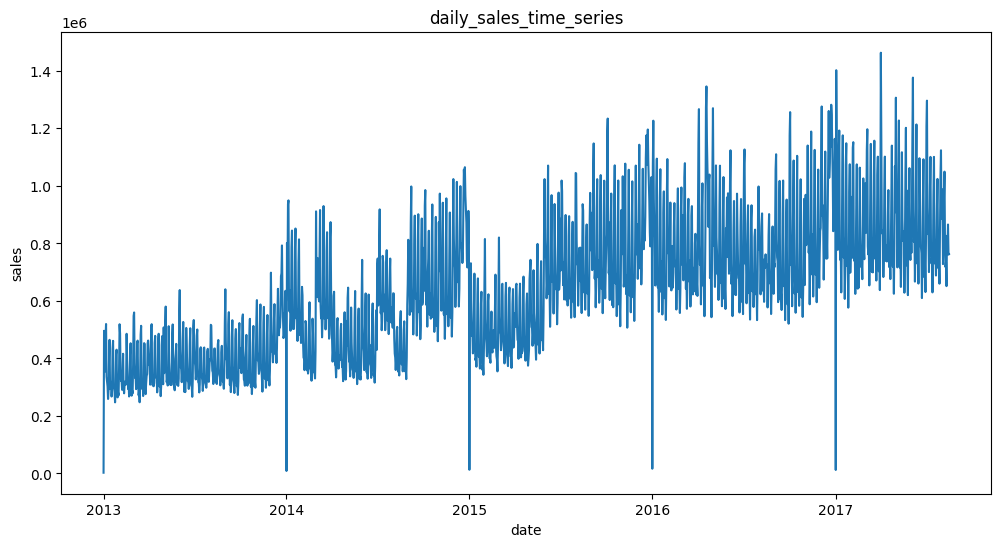

In [22]:
plt.figure(figsize=(12,6))
plt.plot(daily_sales["date"], daily_sales["sales"])
plt.xlabel("date")
plt.ylabel("sales")
plt.title("daily_sales_time_series")


In [23]:
daily_sales["rolling_7"]=daily_sales["sales"].rolling(7,min_periods=1).mean()

In [24]:
daily_sales["rolling_7"].head(10)

0      2511.618999
1    249302.018471
2    286688.422689
3    303631.236290
4    338375.013278
5    368595.077913
6    363956.181220
7    409075.632504
8    381423.974086
9    366784.084361
Name: rolling_7, dtype: float64

In [25]:
daily_sales["date"].dtype

dtype('<M8[us]')

In [26]:
daily_sales["day_week"]=daily_sales["date"].dt.day_name()

In [27]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

In [28]:
 weekly_sales = daily_sales.groupby("day_week")["sales"].mean().reindex(day_order).reset_index()

Text(0.5, 1.0, 'Average Sales by Day of Weplt.show()')

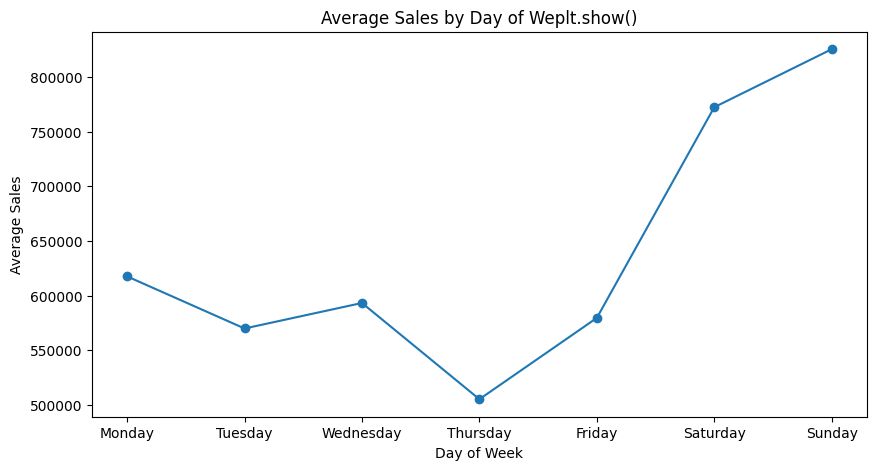

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(
    weekly_sales["day_week"],
    weekly_sales["sales"],
    marker="o"
)

plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.title("Average Sales by Day of Weplt.show()")


In [30]:
daily_sales["month"] = daily_sales["date"].dt.month

In [31]:
monthly_sales = daily_sales.groupby("month")["sales"].mean() .reset_index()


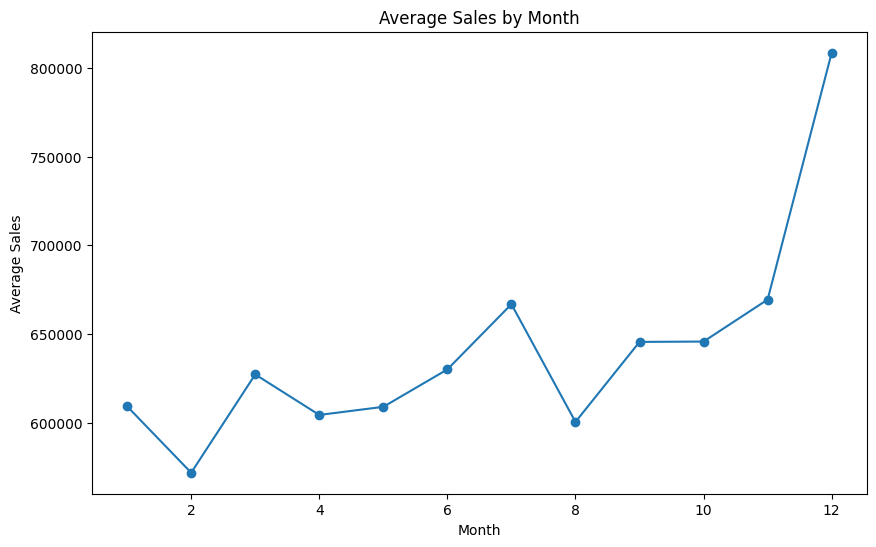

In [32]:
plt.figure(figsize=(10,6))
plt.plot(monthly_sales["month"], monthly_sales["sales"], marker="o")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.title("Average Sales by Month")
plt.show()


In [33]:
daily_sales["year"] = daily_sales["date"].dt.year

In [34]:
yearly_sales = (
    daily_sales.groupby("year")["sales"]
    .mean()
    .reset_index()
)

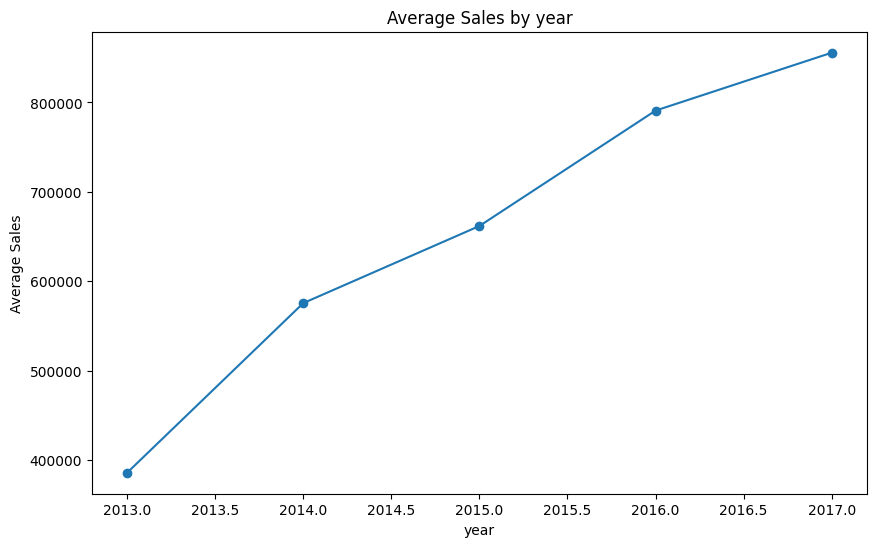

In [35]:
plt.figure(figsize=(10,6))
plt.plot(yearly_sales["year"], yearly_sales["sales"], marker="o")
plt.xlabel("year")
plt.ylabel("Average Sales")
plt.title("Average Sales by year")
plt.show()


In [36]:
daily_sales["daily_change"] = daily_sales["sales"].diff()

In [37]:
daily_sales.nlargest(10, "daily_change")

,date,sales,rolling_7,day_week,month,year,daily_change
1458,2017-01-02,1.402306e+06,910737.451810,Monday,1,2017,1.390224e+06
1093,2016-01-02,1.066677e+06,796565.309119,Saturday,1,2016,1.050244e+06
365,2014-01-02,8.010112e+05,498285.638470,Thursday,1,2014,7.924092e+05
729,2015-01-02,6.577634e+05,665544.601002,Friday,1,2015,6.449898e+05
1547,2017-04-01,1.463084e+06,913242.288099,Saturday,4,2017,5.843339e+05
1,2013-01-02,4.960924e+05,249302.018471,Wednesday,1,2013,4.935808e+05
423,2014-03-01,9.113603e+05,466351.181220,Saturday,3,2014,4.857355e+05
1366,2016-10-01,1.175034e+06,747888.080593,Saturday,10,2016,4.718352e+05
1199,2016-04-17,1.271834e+06,762566.317051,Sunday,4,2016,4.097122e+05
1638,2017-07-01,1.207530e+06,843244.145940,Saturday,7,2017,4.052568e+05


In [38]:
daily_sales.nsmallest(10, "daily_change")

,date,sales,rolling_7,day_week,month,year,daily_change
1457,2017-01-01,12082.500997,857946.648677,Sunday,1,2017,-1.096930e+06
1092,2016-01-01,16433.394000,779429.275677,Friday,1,2016,-9.482081e+05
728,2015-01-01,12773.616980,696163.895976,Thursday,1,2015,-8.316069e+05
364,2014-01-01,8602.065404,451102.772237,Wednesday,1,2014,-4.986626e+05
1186,2016-04-04,795237.192063,854873.824866,Monday,4,2016,-4.716711e+05
1612,2017-06-05,912693.851100,964451.057017,Monday,6,2017,-4.638177e+05
1410,2016-11-14,735723.172977,816266.122558,Monday,11,2016,-4.532591e+05
1584,2017-05-08,776307.495015,910304.333160,Monday,5,2017,-4.510731e+05
1619,2017-06-12,768349.758952,869499.830287,Monday,6,2017,-4.453242e+05
1005,2015-10-05,809524.837996,881486.485444,Monday,10,2015,-4.246061e+05


In [39]:
daily_sales.shape

(1684, 7)

In [40]:
split_index = int(len(daily_sales) * 0.8)

train = daily_sales.iloc[:split_index].copy()
test = daily_sales.iloc[split_index:].copy()

In [41]:
print("Train:", train.shape)
print("Test:", test.shape)

print("Train end:", train["date"].max())
print("Test start:", test["date"].min())

Train: (1347, 7)
Test: (337, 7)
Train end: 2016-09-11 00:00:00
Test start: 2016-09-12 00:00:00


In [42]:
last_train_sales = train["sales"].iloc[-1]

In [43]:
test["baseline_prediction"] = last_train_sales

In [ ]:
from sklearn.metrics import mean_absolute_error

baseline_mae = mean_absolute_error(
    test["sales"],
    test["baseline_prediction"]
)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 219514.76843386047


In [73]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [74]:
baseline_mse=mean_squared_error(test["sales"],test["baseline_prediction"]) 

In [77]:
baseline_rmse=mean_squared_error(test["sales"],test["baseline_prediction"]) 

In [45]:
forecast_df = daily_sales.copy()

In [46]:
forecast_df["lag_1"] = forecast_df["sales"].shift(1)

In [47]:
forecast_df["lag_7"]=forecast_df["sales"].shift(7)

In [48]:
forecast_df["lag_14"] = forecast_df["sales"].shift(14)

In [49]:
forecast_df.head(20)

,date,sales,rolling_7,day_week,month,year,daily_change,lag_1,lag_7,lag_14
0,2013-01-01,2511.618999,2511.618999,Tuesday,1,2013,NaN,NaN,NaN,NaN
1,2013-01-02,496092.417944,249302.018471,Wednesday,1,2013,493580.798945,2511.618999,NaN,NaN
2,2013-01-03,361461.231124,286688.422689,Thursday,1,2013,-134631.186820,496092.417944,NaN,NaN
3,2013-01-04,354459.677093,303631.236290,Friday,1,2013,-7001.554031,361461.231124,NaN,NaN
4,2013-01-05,477350.121229,338375.013278,Saturday,1,2013,122890.444136,354459.677093,NaN,NaN
5,2013-01-06,519695.401088,368595.077913,Sunday,1,2013,42345.279859,477350.121229,NaN,NaN
6,2013-01-07,336122.801066,363956.181220,Monday,1,2013,-183572.600022,519695.401088,NaN,NaN
7,2013-01-08,318347.777981,409075.632504,Tuesday,1,2013,-17775.023085,336122.801066,2511.618999,NaN
8,2013-01-09,302530.809018,381423.974086,Wednesday,1,2013,-15816.968963,318347.777981,496092.417944,NaN
9,2013-01-10,258982.003049,366784.084361,Thursday,1,2013,-43548.805969,302530.809018,361461.231124,NaN


In [50]:
forecast_df.columns

Index(['date', 'sales', 'rolling_7', 'day_week', 'month', 'year',
       'daily_change', 'lag_1', 'lag_7', 'lag_14'],
      dtype='str')

In [51]:
features = ["lag_1", "lag_7", "lag_14", "month", "year"]

X = forecast_df[features]
y = forecast_df["sales"] 

In [58]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [52]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [59]:
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [60]:
predictions = model.predict(X_test)

In [61]:
predictions[:10]

array([746662.36582013, 653710.83479978, 683488.59395117, 610279.1049866 ,
       674184.94694934, 888666.50050413, 953456.63224204, 756086.97229485,
       603369.90605898, 630679.16139189])

In [66]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [67]:
model_mae = mean_absolute_error(y_test, predictions)

model_rmse = mean_squared_error(y_test, predictions) ** 0.5

print("Model MAE:", model_mae)
print("Model RMSE:", model_rmse)

Model MAE: 102152.31839137743
Model RMSE: 146905.09727560735


In [78]:
print("Baseline MAE :", baseline_mae)
print("Model MAE    :", model_mae)

print("Baseline RMSE:", baseline_rmse)
print("Model RMSE   :", model_rmse)

Baseline MAE : 219514.76843386047
Model MAE    : 102152.31839137743
Baseline RMSE: 63194756284.194885
Model RMSE   : 146905.09727560735


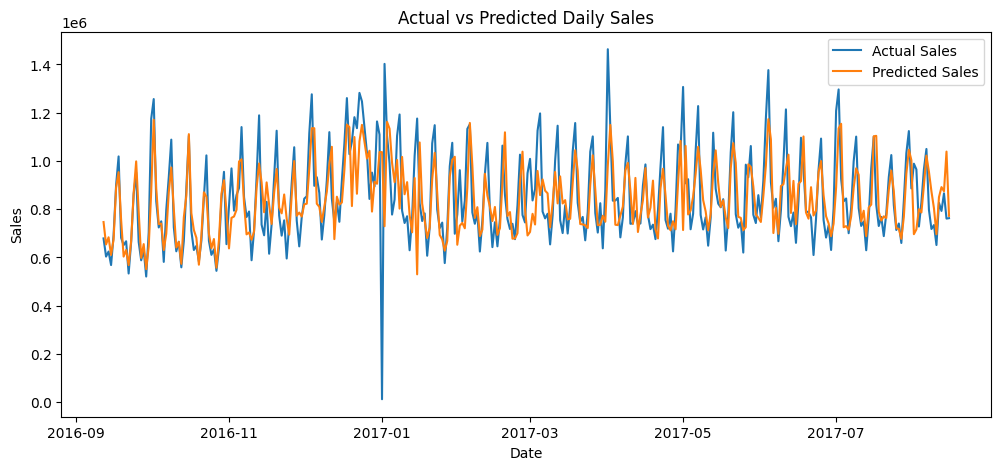

In [79]:
test_dates = forecast_df["date"].iloc[split_index:]

plt.figure(figsize=(12, 5))

plt.plot(test_dates, y_test.values, label="Actual Sales")
plt.plot(test_dates, predictions, label="Predicted Sales")

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Daily Sales")
plt.legend()

plt.show()

In [80]:
import joblib
joblib.dump(model,"random_forest.model.pkl")

['random_forest.model.pkl']